Imágenes: (1797, 8, 8) | Clases: [0 1 2 3 4 5 6 7 8 9]


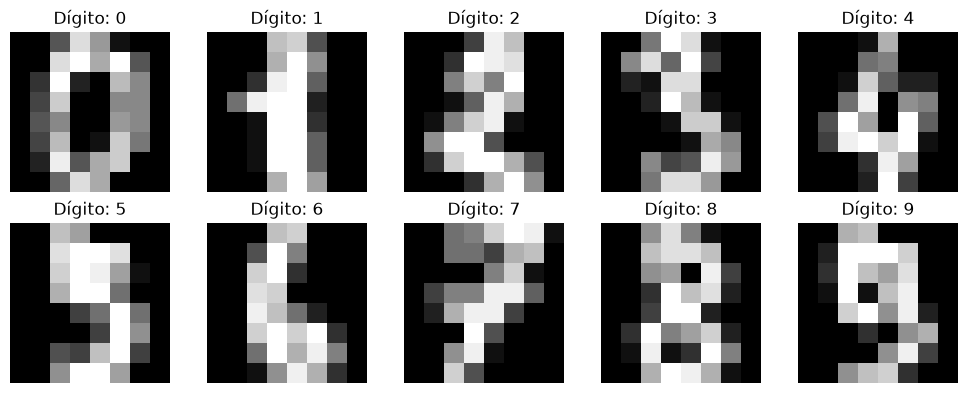

Entrenamiento: X=(1437, 64), y=(1437, 10)
Prueba:        X=(360, 64), y=(360, 10)


In [2]:
# PREPARACIÓN COMÚN — Laboratorio de la semana 3
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Reproducibilidad: semillas para Python, NumPy y TensorFlow.
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# 2. Cargar y explorar imágenes de 8 x 8 y sus etiquetas (0 a 9).
digits = load_digits()
images = digits.images
y_labels = digits.target
print(f"Imágenes: {images.shape} | Clases: {np.unique(y_labels)}")
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flat, images[:10], y_labels[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Dígito: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# 3. Aplanar cada imagen: 8 x 8 -> 64 características.
X = images.reshape(len(images), -1).astype(np.float32)

# 4. Separar ANTES de ajustar el escalador; conservar proporciones por clase.
X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
    X, y_labels, test_size=0.2, random_state=SEED, stratify=y_labels
)

# 5. Aprender media y desviación SOLO de entrenamiento (evita fuga de datos).
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

# Etiquetas one-hot: una columna por cada dígito.
encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
y_train = encoder.fit_transform(y_train_labels.reshape(-1, 1))
y_test = encoder.transform(y_test_labels.reshape(-1, 1))
print(f"Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Prueba:        X={X_test.shape}, y={y_test.shape}")

# 6. Construir una red nueva con la misma semilla para cada experimento.
def build_model(activation="tanh"):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    return tf.keras.Sequential([
        tf.keras.Input(shape=(64,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])

# 7. Entrenar y guardar métricas. Pasar un optimizador NUEVO en cada llamada.
# validation_data es opcional: reservar X_test/y_test para evaluación final.
def train_model(optimizer, activation="tanh", batch_size=32, epochs=50,
                validation_data=None):
    model = build_model(activation=activation)
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
        verbose=0,
    )
    return model, history.history


def evaluate_model(model):
    """Devuelve loss y accuracy sobre el conjunto de prueba."""
    return model.evaluate(X_test, y_test, verbose=0, return_dict=True)


def plot_histories(histories, metric="loss", title=None):
    """histories: diccionario {nombre_experimento: history.history}."""
    fig, ax = plt.subplots(figsize=(10, 5))
    for name, metrics in histories.items():
        values = metrics[metric]
        ax.plot(np.arange(1, len(values) + 1), values, label=name)
    ax.set_xlabel("Época")
    ax.set_ylabel(metric)
    ax.set_title(title or f"Comparación de {metric}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

# Aquí solo preparamos los datos y las funciones; los experimentos van después.


Entrenando Gradient Descent (GD) | batch_size=1437 | épocas=50
  Loss final: 2.3372 | Accuracy de entrenamiento: 0.1955
Entrenando Stochastic GD (SGD) | batch_size=1 | épocas=50
  Loss final: 0.0357 | Accuracy de entrenamiento: 0.9979
Entrenando Mini-Batch SGD | batch_size=32 | épocas=50
  Loss final: 0.9231 | Accuracy de entrenamiento: 0.8246
Entrenando Momentum SGD | batch_size=32 | épocas=50
  Loss final: 0.0204 | Accuracy de entrenamiento: 1.0000
Entrenando Adam | batch_size=32 | épocas=50
  Loss final: 0.0043 | Accuracy de entrenamiento: 1.0000
Entrenando RMSprop | batch_size=32 | épocas=50
  Loss final: 0.0002 | Accuracy de entrenamiento: 1.0000
Entrenando RMSprop + Momentum | batch_size=32 | épocas=50
  Loss final: 0.0000 | Accuracy de entrenamiento: 1.0000


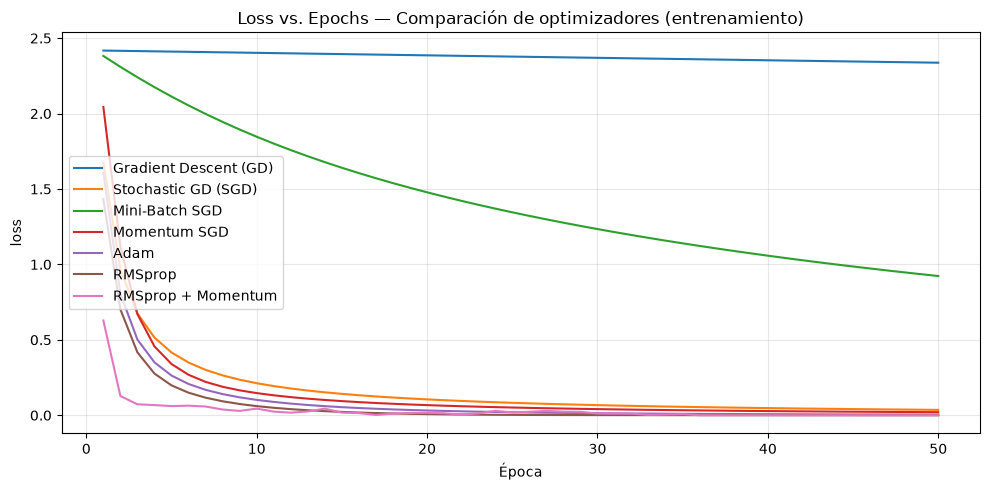

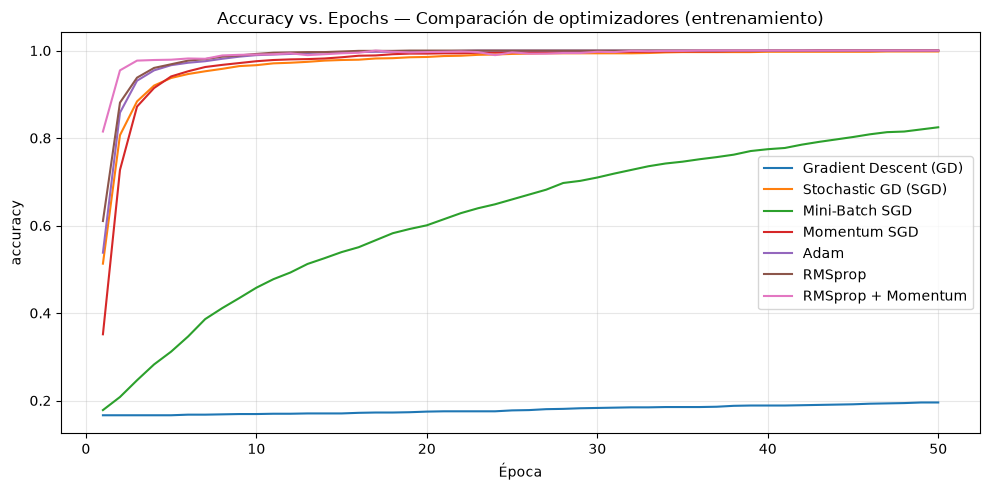

In [3]:
# ACTIVIDAD BASE — Comparación de siete optimizadores
# Ejecutar primero la celda de preparación común.
learning_rate = 0.001
momentum_beta = 0.98
adam_beta1 = 0.9
adam_beta2 = 0.999
rmsprop_rho = 0.9
epochs = 50

# GD, SGD y mini-batch usan SGD: el tamaño del lote distingue los enfoques.
# Cada función crea un optimizador nuevo, con su propio estado.
optimizer_factories = {
    "Gradient Descent (GD)": lambda: tf.keras.optimizers.SGD(
        learning_rate=learning_rate),
    "Stochastic GD (SGD)": lambda: tf.keras.optimizers.SGD(
        learning_rate=learning_rate, momentum=0.0),
    "Mini-Batch SGD": lambda: tf.keras.optimizers.SGD(
        learning_rate=learning_rate, momentum=0.0),
    "Momentum SGD": lambda: tf.keras.optimizers.SGD(
        learning_rate=learning_rate, momentum=momentum_beta),
    "Adam": lambda: tf.keras.optimizers.Adam(
        learning_rate=learning_rate, beta_1=adam_beta1, beta_2=adam_beta2),
    "RMSprop": lambda: tf.keras.optimizers.RMSprop(
        learning_rate=learning_rate, rho=rmsprop_rho),
    "RMSprop + Momentum": lambda: tf.keras.optimizers.RMSprop(
        learning_rate=learning_rate, rho=rmsprop_rho, momentum=momentum_beta),
}

batch_sizes = {
    "Gradient Descent (GD)": X_train.shape[0],  # Todo entrenamiento.
    "Stochastic GD (SGD)": 1,                 # Una muestra por actualización.
    "Mini-Batch SGD": 32,
    "Momentum SGD": 32,
    "Adam": 32,
    "RMSprop": 32,
    "RMSprop + Momentum": 32,
}

# Guardar los modelos y las métricas por época para consultarlos después.
models_base = {}
histories_base = {}
for name, make_optimizer in optimizer_factories.items():
    print(f"Entrenando {name} | batch_size={batch_sizes[name]} | épocas={epochs}",
          flush=True)
    model, history = train_model(
        optimizer=make_optimizer(),
        activation="tanh",
        batch_size=batch_sizes[name],
        epochs=epochs,
    )
    models_base[name] = model
    histories_base[name] = history
    print(f"  Loss final: {history['loss'][-1]:.4f} | "
          f"Accuracy de entrenamiento: {history['accuracy'][-1]:.4f}")

# Las curvas muestran métricas de ENTRENAMIENTO; no son métricas de prueba.
plot_histories(
    histories_base, metric="loss",
    title="Loss vs. Epochs — Comparación de optimizadores (entrenamiento)",
)
plot_histories(
    histories_base, metric="accuracy",
    title="Accuracy vs. Epochs — Comparación de optimizadores (entrenamiento)",
)

# Una época recorre todos los datos, pero el número de actualizaciones cambia
# con el batch_size. SGD con lote 1 suele tardar más por esta razón.


# ACTIVIDAD 1 — Efecto de la tasa de aprendizaje

## Razonamiento

Usamos la misma arquitectura de red con dos optimizadores: **Adam** y **SGD con momentum**. El optimizador determina cómo se actualizan los pesos; no cambia las capas de la red. Probar tres tasas por optimizador da un total de **seis entrenamientos**.

La tasa de aprendizaje controla la escala de las actualizaciones de los pesos. Una tasa pequeña puede producir un avance lento; una alta puede acelerar el aprendizaje, pero también causar oscilaciones o impedir la convergencia. Estas son posibilidades que debemos contrastar con las curvas, no conclusiones anticipadas.

SGD con momentum acumula información de actualizaciones anteriores. Adam utiliza estimaciones del gradiente y de su cuadrado para adaptar las actualizaciones. Por eso, una misma tasa puede tener efectos distintos en cada optimizador.

Para cada optimizador, variamos únicamente la tasa de aprendizaje: **0.001, 0.05 y 0.1**. Mantenemos constantes las demás condiciones:

- Los datos y la división entre entrenamiento y prueba.
- La arquitectura de la red y la semilla.
- La activación `relu` en las capas ocultas.
- El tamaño del lote: **32**.
- El número de épocas: **50**.
- Los parámetros propios de cada optimizador, incluido el momentum de **0.9** para SGD.

Cada entrenamiento comienza con una red y un optimizador nuevos.

La plantilla solicita `relu` en esta actividad, mientras que la actividad base utilizaba `tanh`. Por ello, las comparaciones sobre el efecto de la tasa de aprendizaje se realizan **dentro de esta actividad**.

> Antes de ejecutar, se debe haber ejecutado la celda de preparación común.

## Guía para interpretar los resultados

1. ¿Las tasas altas reducen la pérdida más rápido o producen oscilaciones?
2. ¿La tasa `0.001` necesita más épocas para reducir la pérdida?
3. ¿Qué tasa combina menor pérdida final y mayor estabilidad en cada optimizador?

Estas curvas describen el ajuste a los datos de **entrenamiento**. Una menor pérdida en estos datos no garantiza una mejor exactitud sobre datos nuevos.

Entrenando Adam | lr=0.001
  Loss final de entrenamiento: 0.001130
Entrenando SGD con momentum | lr=0.001
  Loss final de entrenamiento: 0.067135
Entrenando Adam | lr=0.05
  Loss final de entrenamiento: 0.558236
Entrenando SGD con momentum | lr=0.05
  Loss final de entrenamiento: 0.000220
Entrenando Adam | lr=0.1
  Loss final de entrenamiento: 1.556028
Entrenando SGD con momentum | lr=0.1
  Loss final de entrenamiento: 0.010647


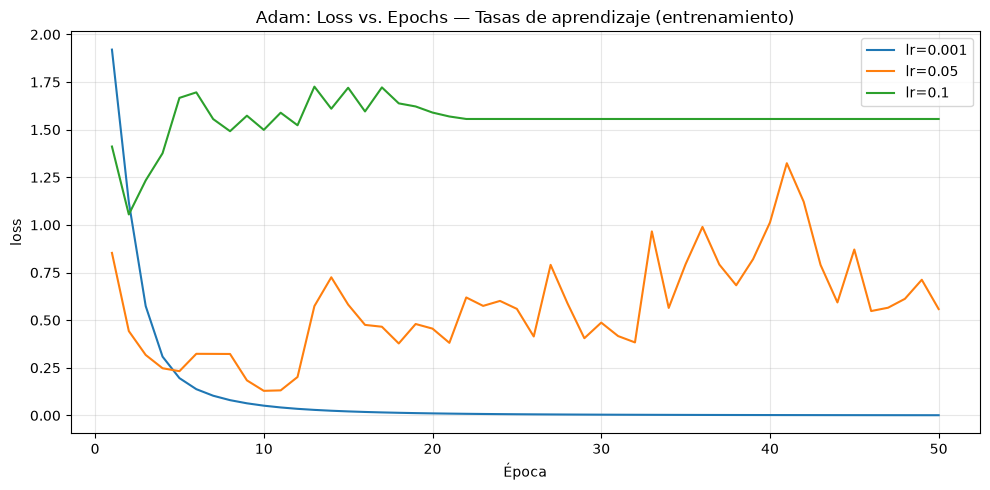

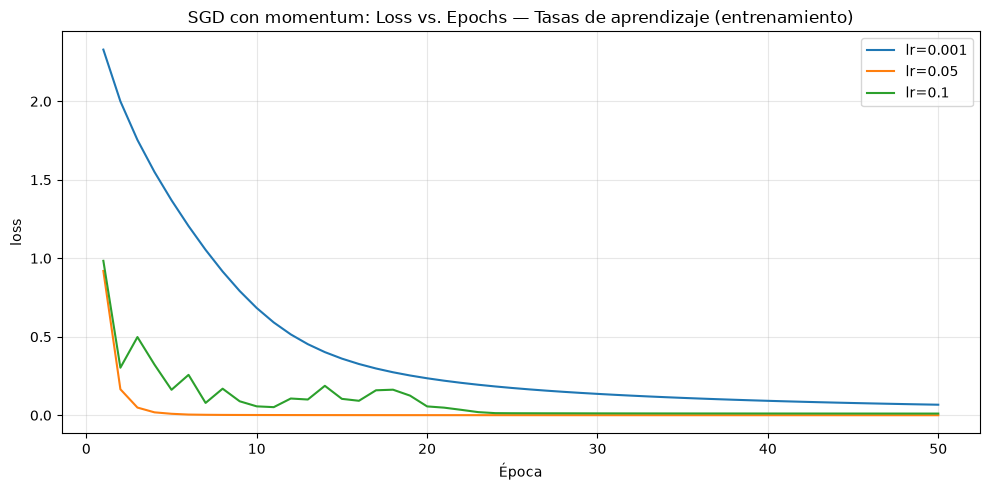

In [4]:
learning_rates_act1 = [0.001, 0.05, 0.1]
momentum_act1 = 0.9
batch_size_act1 = 32
epochs_act1 = 50

histories_act1 = {"Adam": {}, "SGD con momentum": {}}
models_act1 = {"Adam": {}, "SGD con momentum": {}}

for lr in learning_rates_act1:
    # Crear instancias nuevas en cada iteración evita reutilizar su estado.
    optimizers_act1 = {
        "Adam": tf.keras.optimizers.Adam(
            learning_rate=lr, beta_1=0.9, beta_2=0.999
        ),
        "SGD con momentum": tf.keras.optimizers.SGD(
            learning_rate=lr, momentum=momentum_act1
        ),
    }
    for name, optimizer in optimizers_act1.items():
        label = f"lr={lr}"
        print(f"Entrenando {name} | {label}", flush=True)
        model, history = train_model(
            optimizer=optimizer,
            activation="relu",
            batch_size=batch_size_act1,
            epochs=epochs_act1,
        )
        models_act1[name][label] = model
        histories_act1[name][label] = history
        print(f"  Loss final de entrenamiento: {history['loss'][-1]:.6f}")

# Un gráfico por optimizador y tres curvas por gráfico.
for name, histories in histories_act1.items():
    plot_histories(
        histories, metric="loss",
        title=f"{name}: Loss vs. Epochs — Tasas de aprendizaje (entrenamiento)",
    )


# ACTIVIDAD 2 — Efecto del tamaño del mini-batch

## Razonamiento

El tamaño del mini-batch indica cuántas observaciones utiliza la red para calcular el gradiente antes de actualizar sus pesos. Compararemos **16, 64 y 128** con el optimizador **Adam**, lo que da **tres entrenamientos**.

Los lotes pequeños calculan el gradiente con menos ejemplos y suelen producir actualizaciones más variables. Los lotes grandes promedian más ejemplos y pueden producir actualizaciones más estables. Estas tendencias deben contrastarse con los resultados: un lote más grande no garantiza una mejor exactitud de prueba.

Mantendremos los mismos datos, arquitectura y semilla, con activación `relu`, tasa de aprendizaje **0.001**, parámetros de Adam `beta_1=0.9` y `beta_2=0.999`, y **50 épocas**. Cada experimento comienza con una red y un optimizador nuevos. Solo cambia el tamaño del lote.

Con las **1.437 observaciones de entrenamiento**, cada época realiza 90 actualizaciones con lote 16, 23 con lote 64 y 12 con lote 128; el último lote puede ser más pequeño. Por tanto, comparar el mismo número de épocas no equivale a comparar el mismo número de actualizaciones.

Guardaremos la pérdida por época y dibujaremos las tres curvas en un mismo gráfico. Después de cada entrenamiento, evaluaremos el modelo sobre las mismas **360 observaciones de prueba** y mostraremos su exactitud en una tabla.

## Guía para interpretar los resultados

1. ¿Qué curva presenta más oscilaciones? ¿Qué ocurre al reducir el tamaño del lote?
2. ¿Qué tamaño reduce la pérdida más rápido a lo largo de las épocas?
3. ¿Qué tamaño obtiene la mayor exactitud en prueba? ¿Hay empates?

La pérdida que se grafica es un promedio por época, por lo que puede ocultar variaciones entre mini-batches. La exactitud de prueba se calcula al terminar el entrenamiento y no es la misma métrica que la pérdida de entrenamiento.

La comparación en prueba sigue lo solicitado por el laboratorio. Para elegir hiperparámetros en un proyecto real, usaríamos validación y reservaríamos prueba para la evaluación final.

> Ejecutar primero la celda de preparación común. Las conclusiones se redactan después de observar los resultados.


Entrenando Adam | batch_size=16 | épocas=50
  Loss final: 0.000312 | Accuracy de prueba: 96.94%
Entrenando Adam | batch_size=64 | épocas=50
  Loss final: 0.003327 | Accuracy de prueba: 96.67%
Entrenando Adam | batch_size=128 | épocas=50
  Loss final: 0.009645 | Accuracy de prueba: 96.94%


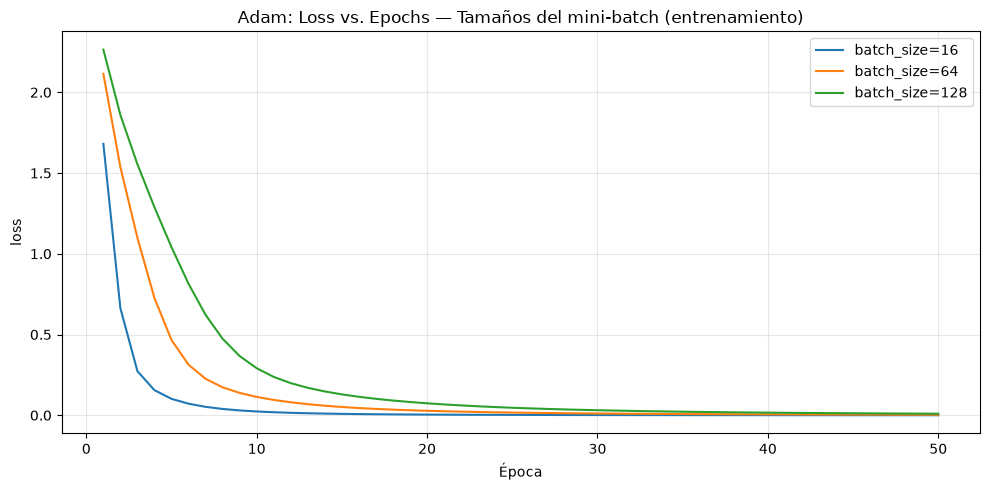

,Batch size,Actualizaciones por época,Loss final (entrenamiento),Loss (prueba),Accuracy (prueba)
0,16,90,0.000312,0.153088,96.94%
1,64,23,0.003327,0.138279,96.67%
2,128,12,0.009645,0.133853,96.94%


Mayor accuracy de prueba: 96.94%
Tamaño(s) de lote con ese resultado: [16, 128]


In [5]:
# ACTIVIDAD 2 — Comparación de tamaños del mini-batch con Adam
import pandas as pd
from IPython.display import display

batch_sizes_act2 = [16, 64, 128]
learning_rate_act2 = 0.001
epochs_act2 = 50

histories_act2 = {}
models_act2 = {}
test_metrics_act2 = {}
summary_act2 = []

for bs in batch_sizes_act2:
    label = f"batch_size={bs}"
    print(f"Entrenando Adam | {label} | épocas={epochs_act2}", flush=True)
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate_act2, beta_1=0.9, beta_2=0.999
    )
    model, history = train_model(
        optimizer=optimizer,
        activation="relu",
        batch_size=bs,
        epochs=epochs_act2,
    )
    # Evaluar después de entrenar: prueba no participa en las actualizaciones.
    test_metrics = evaluate_model(model)
    models_act2[bs] = model
    histories_act2[label] = history
    test_metrics_act2[bs] = test_metrics
    summary_act2.append({
        "Batch size": bs,
        "Actualizaciones por época": (len(X_train) + bs - 1) // bs,
        "Loss final (entrenamiento)": history["loss"][-1],
        "Loss (prueba)": test_metrics["loss"],
        "Accuracy (prueba)": test_metrics["accuracy"],
    })
    print(f"  Loss final: {history['loss'][-1]:.6f} | "
          f"Accuracy de prueba: {test_metrics['accuracy']:.2%}")

# Tres curvas de pérdida de entrenamiento; solo resultados de esta actividad.
plot_histories(
    histories_act2, metric="loss",
    title="Adam: Loss vs. Epochs — Tamaños del mini-batch (entrenamiento)",
)

# Tabla comparativa: conservar valores completos y formatear solo su presentación.
results_act2 = pd.DataFrame(summary_act2)
display(results_act2.style.format({
    "Loss final (entrenamiento)": "{:.6f}",
    "Loss (prueba)": "{:.6f}",
    "Accuracy (prueba)": "{:.2%}",
}))

# Identificar el mayor accuracy observado, incluyendo posibles empates.
best_accuracy_act2 = results_act2["Accuracy (prueba)"].max()
best_batches_act2 = results_act2.loc[
    np.isclose(results_act2["Accuracy (prueba)"], best_accuracy_act2,
               rtol=0, atol=1e-8),
    "Batch size",
].tolist()
print(f"Mayor accuracy de prueba: {best_accuracy_act2:.2%}")
print(f"Tamaño(s) de lote con ese resultado: {best_batches_act2}")
# El resultado corresponde a esta partición y semilla; analizar también las curvas.


# ACTIVIDAD 4 — Comparación de funciones de activación

## Razonamiento

La función de activación transforma la salida de cada neurona e introduce no linealidad, lo que permite aprender relaciones que una sucesión de capas lineales no podría representar. Compararemos **relu, sigmoid y tanh** en las dos capas ocultas: una red nueva por activación, para un total de **tres entrenamientos**.

- **relu:** devuelve cero para entradas negativas y conserva las positivas. Algunas neuronas pueden dejar de recibir gradiente si permanecen en la región negativa.
- **sigmoid:** transforma la entrada a valores entre 0 y 1. Cuando se aproxima a esos extremos, su gradiente se vuelve pequeño y el aprendizaje puede ralentizarse.
- **tanh:** transforma la entrada a valores entre -1 y 1. Está centrada en cero, pero también puede saturarse y producir gradientes pequeños.

Estas propiedades ayudan a interpretar las curvas; no determinan de antemano cuál ganará en este experimento.

Solo cambiaremos la activación de las capas ocultas. Mantendremos los mismos datos, arquitectura de 64 y 32 neuronas, semilla e inicialización, con **Adam**, tasa de aprendizaje **0.001**, `beta_1=0.9`, `beta_2=0.999`, lote de **64** y **50 épocas**. La capa de salida conserva **softmax** y sus diez clases. Cada entrenamiento comienza con una red y un optimizador nuevos.

Graficaremos **Accuracy vs. Epochs** con las tres curvas de entrenamiento y compararemos la exactitud de la última época. Como complemento, evaluaremos cada modelo en prueba y mostraremos ambos resultados por separado en una tabla.

## Guía para interpretar los resultados

1. ¿Qué activación aumenta la exactitud más rápido durante las primeras épocas?
2. ¿Cuál obtiene la mayor exactitud de entrenamiento en la última época? ¿Hay empates?
3. ¿La mejor activación en entrenamiento también obtiene el mejor resultado en prueba?

Una exactitud alta en entrenamiento no garantiza el mismo resultado en datos nuevos. Las conclusiones corresponden a esta configuración, semilla y partición; no establecen una activación universalmente superior.

> Ejecutar primero la celda de preparación común. Esta actividad puede ejecutarse sin las actividades intermedias.


Entrenando Adam | activación=relu | épocas=50
  Accuracy última época: 100.00% | Accuracy de prueba: 96.67%
Entrenando Adam | activación=sigmoid | épocas=50
  Accuracy última época: 99.10% | Accuracy de prueba: 96.39%
Entrenando Adam | activación=tanh | épocas=50
  Accuracy última época: 100.00% | Accuracy de prueba: 96.39%


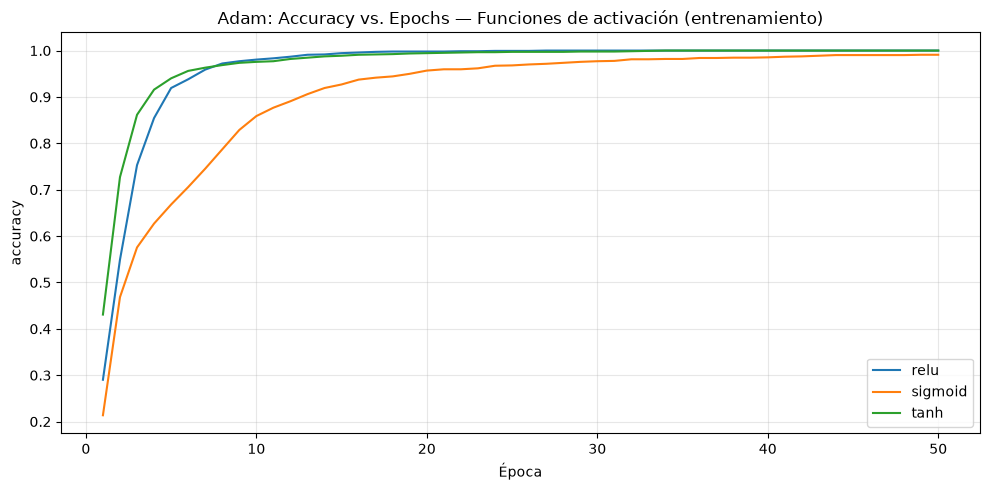

,Activación,Accuracy final (entrenamiento),Accuracy (prueba)
0,relu,100.00%,96.67%
1,sigmoid,99.10%,96.39%
2,tanh,100.00%,96.39%


Accuracy final (entrenamiento): 100.00% | Mejor(es): relu, tanh
Accuracy (prueba): 96.67% | Mejor(es): relu


In [6]:
# ACTIVIDAD 4 — Comparar relu, sigmoid y tanh con Adam
import pandas as pd
from IPython.display import display

activations_act4 = ["relu", "sigmoid", "tanh"]
learning_rate_act4 = 0.001
batch_size_act4 = 64
epochs_act4 = 50

histories_act4 = {}
models_act4 = {}
test_metrics_act4 = {}
summary_act4 = []

for activation in activations_act4:
    print(f"Entrenando Adam | activación={activation} | épocas={epochs_act4}",
          flush=True)
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate_act4, beta_1=0.9, beta_2=0.999
    )
    # build_model, llamada por train_model, conserva softmax en la salida.
    model, history = train_model(
        optimizer=optimizer,
        activation=activation,
        batch_size=batch_size_act4,
        epochs=epochs_act4,
    )
    test_metrics = evaluate_model(model)
    histories_act4[activation] = history
    models_act4[activation] = model
    test_metrics_act4[activation] = test_metrics
    summary_act4.append({
        "Activación": activation,
        "Accuracy final (entrenamiento)": history["accuracy"][-1],
        "Accuracy (prueba)": test_metrics["accuracy"],
    })
    print(f"  Accuracy última época: {history['accuracy'][-1]:.2%} | "
          f"Accuracy de prueba: {test_metrics['accuracy']:.2%}")

# Tres curvas: exactitud registrada DURANTE cada época de entrenamiento.
plot_histories(
    histories_act4, metric="accuracy",
    title="Adam: Accuracy vs. Epochs — Funciones de activación (entrenamiento)",
)

# Conservar los valores numéricos; formatear una copia para mostrar porcentajes.
results_act4 = pd.DataFrame(summary_act4)
table_act4 = results_act4.copy()
for column in ["Accuracy final (entrenamiento)", "Accuracy (prueba)"]:
    table_act4[column] = table_act4[column].map(lambda value: f"{value:.2%}")
display(table_act4)

# Comparar por separado la última época y la evaluación en prueba.
# Si varias activaciones empatan, se muestran todas.
best_activations_act4 = {}
for metric in ["Accuracy final (entrenamiento)", "Accuracy (prueba)"]:
    best_accuracy = results_act4[metric].max()
    best_activations_act4[metric] = results_act4.loc[
        np.isclose(results_act4[metric], best_accuracy, rtol=0, atol=1e-8),
        "Activación",
    ].tolist()
    print(f"{metric}: {best_accuracy:.2%} | "
          f"Mejor(es): {', '.join(best_activations_act4[metric])}")


# ACTIVIDAD 5 — Comparación estadística entre MLP y Random Forest

## Diseño e hipótesis

Utilizamos las 1.797 imágenes de dígitos de `load_digits` y validación cruzada estratificada de 10 folds. Ambos modelos se evalúan sobre las mismas particiones, por lo que sus resultados están pareados.

Definimos la diferencia como:

`d_i = accuracy_RandomForest,i − accuracy_MLP,i`

Una diferencia positiva favorece a Random Forest; una negativa favorece al MLP.

Para el **t-test pareado**:

- **H₀:** la media poblacional de las diferencias es cero.
- **H₁:** la media poblacional de las diferencias es distinta de cero.

Para **Wilcoxon**:

- **H₀:** la distribución de las diferencias es simétrica alrededor de cero.
- **H₁:** la distribución de las diferencias no es simétrica alrededor de cero.

Ambas pruebas son bilaterales. Con **α = 0.05**, rechazamos H₀ si `p ≤ 0.05`; en caso contrario, no la rechazamos.

In [7]:
# ACTIVIDAD 5 — MLP vs. Random Forest: comparación estadística pareada
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, wilcoxon

# Dataset completo de imágenes de dígitos; no modificar los datos anteriores.
X_act5, y_act5 = load_digits(return_X_y=True)
alpha_act5 = 0.05
cv_act5 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_mlp_act5, scores_rf_act5 = [], []

for fold, (tr, te) in enumerate(cv_act5.split(X_act5, y_act5), start=1):
    # Modelos nuevos por fold. El escalador aprende SOLO del entrenamiento.
    model_mlp = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0),
    )
    model_rf = RandomForestClassifier(n_estimators=200, random_state=0)
    model_mlp.fit(X_act5[tr], y_act5[tr])
    model_rf.fit(X_act5[tr], y_act5[tr])
    acc_mlp = accuracy_score(y_act5[te], model_mlp.predict(X_act5[te]))
    acc_rf = accuracy_score(y_act5[te], model_rf.predict(X_act5[te]))
    scores_mlp_act5.append(acc_mlp)
    scores_rf_act5.append(acc_rf)
    print(f"Fold {fold:2d}/10 | MLP={acc_mlp:.4f} | RF={acc_rf:.4f}", flush=True)

sc_A_act5 = np.array(scores_mlp_act5)
sc_B_act5 = np.array(scores_rf_act5)
d_act5 = sc_B_act5 - sc_A_act5  # Positivo favorece RF; negativo favorece MLP.
fold_results_act5 = pd.DataFrame({
    "Fold": np.arange(1, 11),
    "Accuracy MLP": sc_A_act5,
    "Accuracy Random Forest": sc_B_act5,
    "Diferencia RF - MLP": d_act5,
})
display(fold_results_act5.round(6))
print(f"MLP: {sc_A_act5.mean():.4%} +/- {sc_A_act5.std(ddof=1):.4%} (DE entre folds)")
print(f"RF : {sc_B_act5.mean():.4%} +/- {sc_B_act5.std(ddof=1):.4%} (DE entre folds)")
print(f"Diferencia media RF - MLP: {d_act5.mean():.6f} "
      f"= {100 * d_act5.mean():.4f} puntos porcentuales")

# t-test: H0: media poblacional(d)=0; H1: media poblacional(d)!=0.
t_act5, p_t_act5 = ttest_rel(sc_B_act5, sc_A_act5, alternative="two-sided")
# Wilcoxon: H0: distribución de d simétrica alrededor de cero.
# Redondear solo para los rangos evita romper empates por errores numéricos.
d_wilcoxon_act5 = np.round(d_act5, 12)
if np.all(d_wilcoxon_act5 == 0):
    w_act5, p_w_act5 = 0.0, 1.0
else:
    w_act5, p_w_act5 = wilcoxon(d_wilcoxon_act5, alternative="two-sided")

# Cohen's d pareado (d_z): tamaño del efecto, NO prueba de significancia.
sd_diff_act5 = d_act5.std(ddof=1)
cohen_d_act5 = d_act5.mean() / sd_diff_act5 if sd_diff_act5 > 0 else np.nan

# Bootstrap pareado: remuestrear diferencias completas, nunca A y B por separado.
rng_act5 = np.random.default_rng(123)
boot_act5 = np.array([
    rng_act5.choice(d_act5, size=len(d_act5), replace=True).mean()
    for _ in range(10000)
])
ci_low_act5, ci_high_act5 = np.percentile(boot_act5, [2.5, 97.5])

print(f"\nDECISIONES — alpha={alpha_act5}")
for name, statistic, p_value in [
    ("t-test pareado", t_act5, p_t_act5),
    ("Wilcoxon", w_act5, p_w_act5),
]:
    decision = "RECHAZO H0" if p_value <= alpha_act5 else "NO rechazo H0"
    print(f"{name}: estadístico={statistic:.6f}, p={p_value:.6f} -> {decision}")
print("No rechazar H0 no demuestra equivalencia entre modelos.")

abs_effect_act5 = abs(cohen_d_act5)
if not np.isfinite(abs_effect_act5):
    effect_size_act5 = "no definido: desviación de las diferencias igual a cero"
elif abs_effect_act5 < 0.2:
    effect_size_act5 = "menor que pequeño"
elif abs_effect_act5 < 0.5:
    effect_size_act5 = "pequeño"
elif abs_effect_act5 < 0.8:
    effect_size_act5 = "mediano"
else:
    effect_size_act5 = "grande"
print(f"Cohen's d_z={cohen_d_act5:.6f} | Magnitud orientativa: {effect_size_act5}")
print("Cohen's d_z no tiene p-valor; su signo sigue RF - MLP.")
print(f"IC bootstrap 95%: [{ci_low_act5:.6f}, {ci_high_act5:.6f}]")
print(f"En puntos porcentuales: [{100*ci_low_act5:.4f}, {100*ci_high_act5:.4f}]")

agree_act5 = (p_t_act5 <= alpha_act5) == (p_w_act5 <= alpha_act5)
includes_zero_act5 = ci_low_act5 <= 0 <= ci_high_act5
print(f"\n¿Coinciden las decisiones de las dos pruebas? {'Sí' if agree_act5 else 'No'}")
print(f"¿El intervalo bootstrap incluye cero? {'Sí' if includes_zero_act5 else 'No'}")
print("Interpretar la magnitud junto con la diferencia en puntos porcentuales.")
print("Los folds comparten datos de entrenamiento: inferencia exploratoria.")


Fold  1/10 | MLP=0.9722 | RF=0.9833
Fold  2/10 | MLP=0.9667 | RF=0.9833
Fold  3/10 | MLP=0.9833 | RF=0.9722
Fold  4/10 | MLP=0.9833 | RF=0.9778
Fold  5/10 | MLP=0.9833 | RF=0.9722
Fold  6/10 | MLP=0.9667 | RF=0.9778
Fold  7/10 | MLP=0.9667 | RF=0.9944
Fold  8/10 | MLP=0.9777 | RF=0.9832
Fold  9/10 | MLP=0.9609 | RF=0.9665
Fold 10/10 | MLP=0.9832 | RF=0.9777


,Fold,Accuracy MLP,Accuracy Random Forest,Diferencia RF - MLP
0,1,0.972222,0.983333,0.011111
1,2,0.966667,0.983333,0.016667
2,3,0.983333,0.972222,-0.011111
3,4,0.983333,0.977778,-0.005556
4,5,0.983333,0.972222,-0.011111
5,6,0.966667,0.977778,0.011111
6,7,0.966667,0.994444,0.027778
7,8,0.977654,0.983240,0.005587
8,9,0.960894,0.966480,0.005587
9,10,0.983240,0.977654,-0.005587


MLP: 97.4401% +/- 0.8786% (DE entre folds)
RF : 97.8849% +/- 0.7798% (DE entre folds)
Diferencia media RF - MLP: 0.004448 = 0.4448 puntos porcentuales

DECISIONES — alpha=0.05
t-test pareado: estadístico=1.100521, p=0.299668 -> NO rechazo H0
Wilcoxon: estadístico=17.000000, p=0.328125 -> NO rechazo H0
No rechazar H0 no demuestra equivalencia entre modelos.
Cohen's d_z=0.348015 | Magnitud orientativa: pequeño
Cohen's d_z no tiene p-valor; su signo sigue RF - MLP.
IC bootstrap 95%: [-0.002781, 0.011679]
En puntos porcentuales: [-0.2781, 1.1679]

¿Coinciden las decisiones de las dos pruebas? Sí
¿El intervalo bootstrap incluye cero? Sí
Interpretar la magnitud junto con la diferencia en puntos porcentuales.
Los folds comparten datos de entrenamiento: inferencia exploratoria.


## Resultados

| Medida | Resultado |
|---|---:|
| Exactitud promedio del MLP | 97.4401 % |
| Exactitud promedio de Random Forest | 97.8849 % |
| Diferencia promedio RF − MLP | +0.4448 puntos porcentuales |
| t-test pareado | t = 1.100521; p = 0.299668 |
| Wilcoxon | W = 17; p = 0.328125 |
| Cohen’s d pareado | 0.348015 |
| IC bootstrap del 95 % de la diferencia | [−0.2781, +1.1679] puntos porcentuales |

## Respuestas

### 1. ¿Coinciden el t-test y Wilcoxon? Si no, ¿a cuál le creemos?

Sí. Ambos p-valores superan 0.05, por lo que **no rechazamos las hipótesis nulas correspondientes**. No encontramos evidencia estadística suficiente para afirmar una diferencia de desempeño con este procedimiento.

No es necesario escoger una prueba. Si discreparan, revisaríamos sus supuestos y las diferencias observadas, en lugar de elegir la que produzca el resultado deseado. No rechazar H₀ tampoco demuestra equivalencia entre modelos.

### 2. ¿El intervalo bootstrap incluye cero? ¿Es coherente con los p-valores?

Sí. El intervalo va de **−0.2781 a +1.1679 puntos porcentuales** e incluye cero.

Esto es coherente con ambas pruebas: los resultados son compatibles con una diferencia promedio nula. El intervalo también contempla una pequeña ventaja del MLP o una ventaja de Random Forest.

### 3. ¿Qué magnitud tiene Cohen’s d? ¿Recomendaríamos cambiar de modelo?

El valor **d = 0.348** corresponde a un efecto pequeño según las referencias orientativas de 0.2, 0.5 y 0.8. Su signo positivo favorece a Random Forest.

Cohen’s d mide el tamaño del efecto; no es una prueba de significancia ni se compara con α.

No recomendaríamos cambiar de modelo únicamente con esta evidencia. Random Forest presenta una ventaja promedio de aproximadamente **0.445 puntos porcentuales**, pero las pruebas no detectan una diferencia estadísticamente significativa. También habría que considerar tiempo de entrenamiento, predicción y necesidades del proyecto.

## Conclusión

Random Forest obtuvo una exactitud promedio ligeramente superior al MLP, con un efecto pequeño, pero las dos pruebas y el intervalo bootstrap no aportan evidencia suficiente para afirmar una ventaja concluyente. Como los folds comparten datos de entrenamiento, esta comparación debe interpretarse como exploratoria.